In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from Toolbox.DBtool import mitArr

FontSize: int = 16  # label font size
plt.rcParams['font.size'] = FontSize - 2
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams["savefig.transparent"] = True
plt.rcParams["savefig.dpi"] = 900
plt.rcParams["savefig.bbox"] = 'tight'
db = mitArr()

data100 = db.record('100')

In [13]:
from GaussECG.two_stage_density_peak_clustering import TwoStageDPC

detector = TwoStageDPC(fs=data100.fs)
detector.clc_params(data100.signal)

Calculation parameters (in block): 100%|██████████| 120/120 [00:04<00:00, 29.70it/s]


In [19]:
# left = len(data100.signal)
left = 50000
r = np.zeros_like(data100.signal[:left])
r[data100.r_loc[data100.r_loc < left]] = 1

In [20]:
data = pd.DataFrame(
    {
        'sig': data100.signal[:left],
        'rho': detector.params.rho[:left],
        'delta': detector.params.delta[:left],
        'r': r
    }
)

In [21]:
def plot(ax1, ax2, x0, y0, bins):
    ax1.scatter(np.arange(len(y0)), y0, s=5, c='#50A7E6')
    ax1.scatter(x0, y0[x0], s=5, c='#E5070E')
    ax1.set_xlim([0, len(y0)])
    ax2.hist(y0, bins=bins, orientation='horizontal', color='#50A7E6', edgecolor='#00000f',alpha=0.7)
    plt.setp(ax2.get_yticklabels(), visible=False)


def remobe_baseline(X):
    _X = np.zeros_like(X)
    d = int(data100.fs)

    Mi = np.empty(len(X) + 1, dtype=np.float64)
    cum_sum = np.concatenate([[0], np.cumsum(X, dtype=np.float64)])
    initial_mean = cum_sum[d] / d
    Mi[:d + 1] = initial_mean
    for i in range(d, len(X)):
        start = i - d + 1
        end = i
        window_sum = cum_sum[end + 1] - cum_sum[start]
        Mi[i + 1] = window_sum / d
    _X[d:] = X[d:] - Mi[d:len(X)]
    return _X

In [22]:
data['delta'].quantile(0.97)

np.float64(10.0)

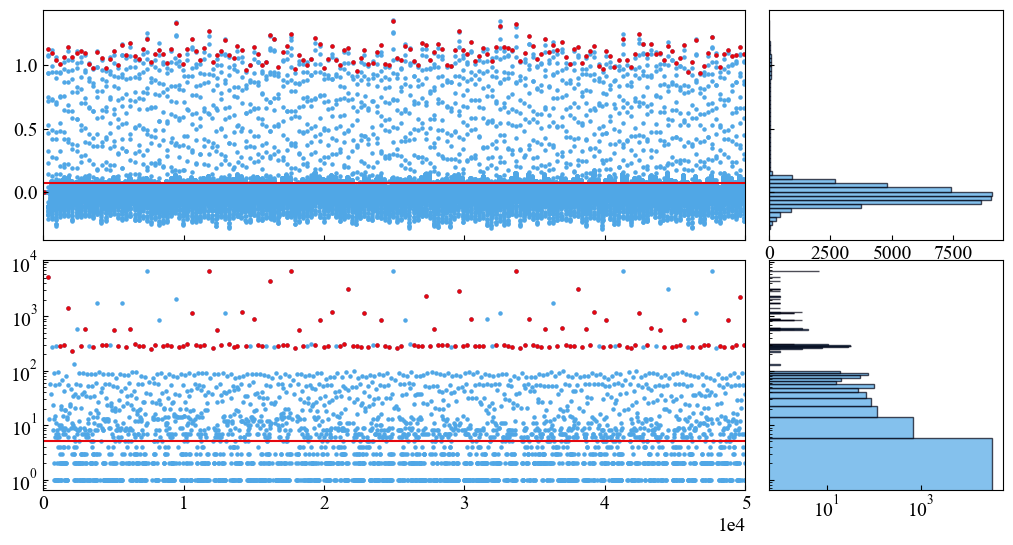

In [25]:
quantile_rho = 0.90
y_rho = remobe_baseline(data['rho'].to_numpy())
y_delta = remobe_baseline(data['delta'].to_numpy())
x = np.where(data['r'] == 1)[0]

fig = plt.figure(figsize=(12, 6))
gs = fig.add_gridspec(2, 2, width_ratios=[3, 1], height_ratios=[1, 1],
                      left=0.1, right=0.9, bottom=0.1, top=0.9,
                      wspace=0.05, hspace=0.09)
ax_main1 = fig.add_subplot(gs[0, 0])
ax_hist1 = fig.add_subplot(gs[0, 1], sharey=ax_main1)
plot(ax_main1, ax_hist1, x, y_rho, bins=50)
ax_main1.axhline(y=np.quantile(y_rho, quantile_rho), color='#E5070E')
ax_main1.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))
ax_main1.set_xticklabels([])

quantile_delta = 0.97
ax_main2 = fig.add_subplot(gs[1, 0])
ax_hist2 = fig.add_subplot(gs[1, 1], sharey=ax_main2)
plot(ax_main2, ax_hist2, x, y_delta,bins=800)
ax_main2.axhline(y=np.quantile(y_delta, quantile_delta), color='#E5070E')
ax_main2.set_yscale('log')
ax_hist2.set_xscale('log')
ax_main2.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))
plt.savefig('temp_a_1.jpg', dpi=900, bbox_inches='tight')

In [8]:
y_rho = data['rho'].loc[data['rho'] > data['rho'].quantile(quantile_rho)].to_numpy()
y_delta = data['delta'].loc[data['delta'] > data['delta'].quantile(quantile_delta)].to_numpy()
x_rho = np.where(data['r'].loc[data['rho'] > data['rho'].quantile(quantile_rho)] == 1)[0]
x_delta = np.where(data['r'].loc[data['delta'] > data['delta'].quantile(quantile_delta)] == 1)[0]

In [9]:
from scipy.optimize import minimize
from scipy.stats import genpareto


def grimshaw(y: np.ndarray, epsilon: float = 1e-8, k: int = 10) -> (float, float):
    ymin = np.min(y)
    ymax = np.max(y)
    ymean = np.mean(y)
    Nt = len(y)

    def log_likelihood(gamma, sigma):
        result = np.zeros_like(gamma)
        for i, (g, s) in enumerate(zip(gamma, sigma)):
            if g != 0:
                result[i] = -Nt * np.log(s) - (1 + 1 / g) * np.sum(
                    np.log(1 + g / s * y))
            else:
                result[i] = Nt * (1 + np.log(np.mean(y)))
        return result

    def u(x):
        return (1 / (1 + x.reshape(-1, 1) * y.reshape(1, -1))).mean(axis=1)

    def v(x):
        return (np.log(1 + x.reshape(-1, 1) * y.reshape(1, -1))).mean(axis=1) + 1

    def w(x):
        return u(x) * v(x) - 1

    def optimization(x):
        return np.sum(w(x) ** 2)

    def gradient(x):
        jac_u = (y / (1 + x.reshape(-1, 1) * y.reshape(1, -1)) ** 2).mean(axis=1)
        jac_v = (y / (1 + x.reshape(-1, 1) * y.reshape(1, -1))).mean(axis=1)
        return jac_u * v(x) + u(x) * jac_v

    if epsilon >= 1 / (2 * ymax):
        epsilon = 1 / (ymax * (k + 1))

    bound1 = (-1 / ymax + epsilon, -epsilon)
    bound2 = (2 * (ymean - ymin) / (ymean * ymin), 2 * (ymean - ymin) / ymin ** 2)

    roots = set()
    for bounds in [bound1, bound2]:
        x0 = np.linspace(bounds[0], bounds[1], k, endpoint=True)
        root = minimize(optimization, x0, method='L-BFGS-B', jac=gradient, bounds=[bounds] * k).x
        roots.update(root)

    roots = np.array(list(roots))
    gammas = v(roots) - 1
    sigmas = gammas / roots
    lle = log_likelihood(gammas, sigmas)

    ii = np.argmax(lle)
    return gammas[ii], sigmas[ii]

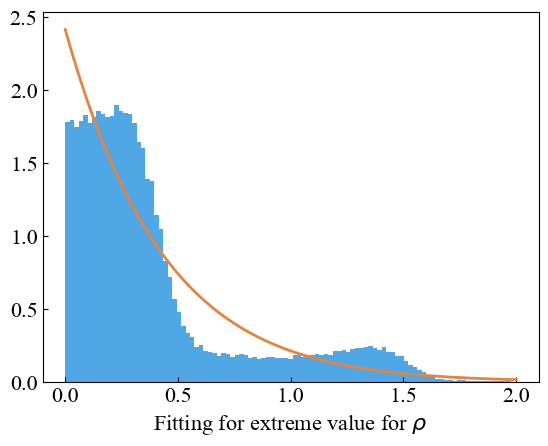

In [10]:
gamma, sigmas = grimshaw(y_rho - data['rho'].quantile(quantile_rho))
plt.hist(y_rho - data['rho'].quantile(quantile_rho), density=True, bins=100, orientation='vertical', color='#50A7E6')
y = genpareto.pdf(np.linspace(0, 2, 100), gamma, loc=0, scale=sigmas)
plt.plot(np.linspace(0, 2, 100), y, linewidth=2, c='#E6843E')
plt.xlabel(r'Fitting for extreme value for $\rho$')
plt.savefig('temp_a_2.jpg', dpi=900, bbox_inches='tight')

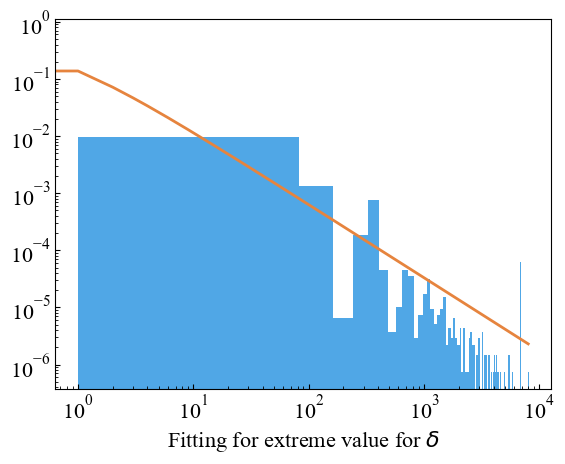

In [11]:
gamma, sigmas = grimshaw(y_delta - data['delta'].quantile(quantile_delta))
plt.hist(y_delta - data['delta'].quantile(quantile_delta), density=True, bins=100, orientation='vertical', color='#50A7E6')
y = genpareto.pdf(np.linspace(0, 8000, 8000), gamma, loc=0, scale=sigmas)
plt.plot(np.linspace(0, 8000, 8000), y, linewidth=2, c='#E6843E')
plt.yscale('log')
plt.xscale('log')
plt.xlabel(r'Fitting for extreme value for $\delta$')
plt.savefig('temp_a_3.jpg', dpi=900, bbox_inches='tight')